In [1]:
from comet import download_model, load_from_checkpoint
from pathlib import Path
import matplotlib.pyplot as plt

/Users/dorianclay/mambaforge/envs/701-proj/lib/python3.12/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
model_path = download_model('Unbabel/wmt22-comet-da')
model = load_from_checkpoint(model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/Users/dorianclay/mambaforge/envs/701-proj/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [3]:
dir = Path('data/tatoeba')

with open(dir/'input.txt', 'r', encoding='utf-8') as f:
    inputs = [line.strip() for line in f.readlines()]

with open(dir/'translation.txt', 'r', encoding='utf-8') as f:
    translations = [line.strip() for line in f.readlines()]

with open(dir/'reference.txt', 'r', encoding='utf-8') as f:
    references = [line.strip() for line in f.readlines()]

with open(dir/'confidence.txt', 'r', encoding='utf-8') as f:
    confidences = [line.strip() for line in f.readlines()]

In [4]:
data = [
    {"src": src, "mt": mt, "ref": ref}
    for src, mt, ref in zip(inputs, translations, references)
]

In [8]:
data

[{'src': 'I really appreciated your help yesterday afternoon.',
  'mt': 'J’ai vraiment apprécié ton aide hier après-midi.',
  'ref': "J'ai vraiment apprécié votre aide, hier après-midi."},
 {'src': "I'd like to talk to the head of security.",
  'mt': 'J’aimerais parler au chef de la sécurité.',
  'ref': "J'aimerais m'entretenir avec la responsable de la sécurité."},
 {'src': 'Since there are usually multiple websites on any given topic, I usually just click the back button when I arrive on any webpage that has pop-up advertising. I just go to the next page found by Google and hope for something less irritating.',
  'mt': 'Comme il y a généralement plusieurs sites web sur un même sujet, je clique simplement sur le bouton « Retour » quand j’arrive sur une page qui contient de la publicité intrusive. Je vais ensuite sur la page suivante trouvée par Google et j’espère tomber sur quelque chose de moins agaçant.',
  'ref': "Puisqu'il y a de multiples sites web sur chaque sujet, je clique d'h

In [5]:
model_output = model.predict(data, batch_size=8)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
Predicting: 0it [00:00, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Predicting DataLoader 0: 100%|████████

In [6]:
model_output.scores

[0.9678370356559753,
 0.8587646484375,
 0.8716312646865845,
 0.6749810576438904,
 0.9522436857223511,
 0.9587529301643372,
 0.45979857444763184,
 0.986228883266449,
 0.8560908436775208,
 0.9086387753486633,
 0.9889480471611023,
 0.9138581156730652,
 0.985481321811676,
 0.9600936770439148,
 0.9423084855079651]

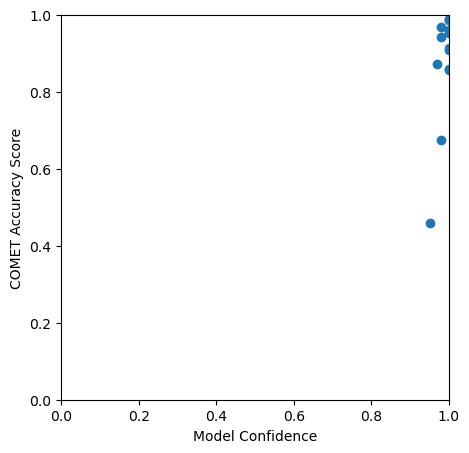

In [7]:
plt.figure(figsize=(5,5))
plt.scatter([float(c) for c in confidences], model_output.scores)
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Model Confidence")
plt.ylabel("COMET Accuracy Score")

plt.savefig('dorian_data.pdf')
plt.show()